In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime 
from datetime import date
import math
#import pandas_datareader as web

In [2]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

In [7]:
def conv_str(column):
    data[column]=data[column].replace(',','',regex=True)
    data[column]=data[column].astype(float)

In [8]:
conv_str('Price')

In [3]:
#data = web.get_data_yahoo('^NSEBANK', start = datetime.datetime(2000, 1, 2), end = date.today())
#data = data[['Adj Close']]
#data.columns = ['Price']
data = pd.read_csv("C:\\Users\\Rishi\\Downloads\\Nifty Bank Historical Data.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date',inplace = True)
data.head()

C:\Users\RISHI\AppData\Local\Temp\ipykernel_13020\1163019021.py:5: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  data['Date'] = pd.to_datetime(data['Date'])


,Price
Date,
2024-08-30,51351.00
2024-08-29,51152.75
2024-08-28,51143.85
2024-08-27,51278.75
2024-08-26,51148.10


In [4]:
print('There are {} number of days in the dataset.'.format(data.shape[0]))

There are 2474 number of days in the dataset.


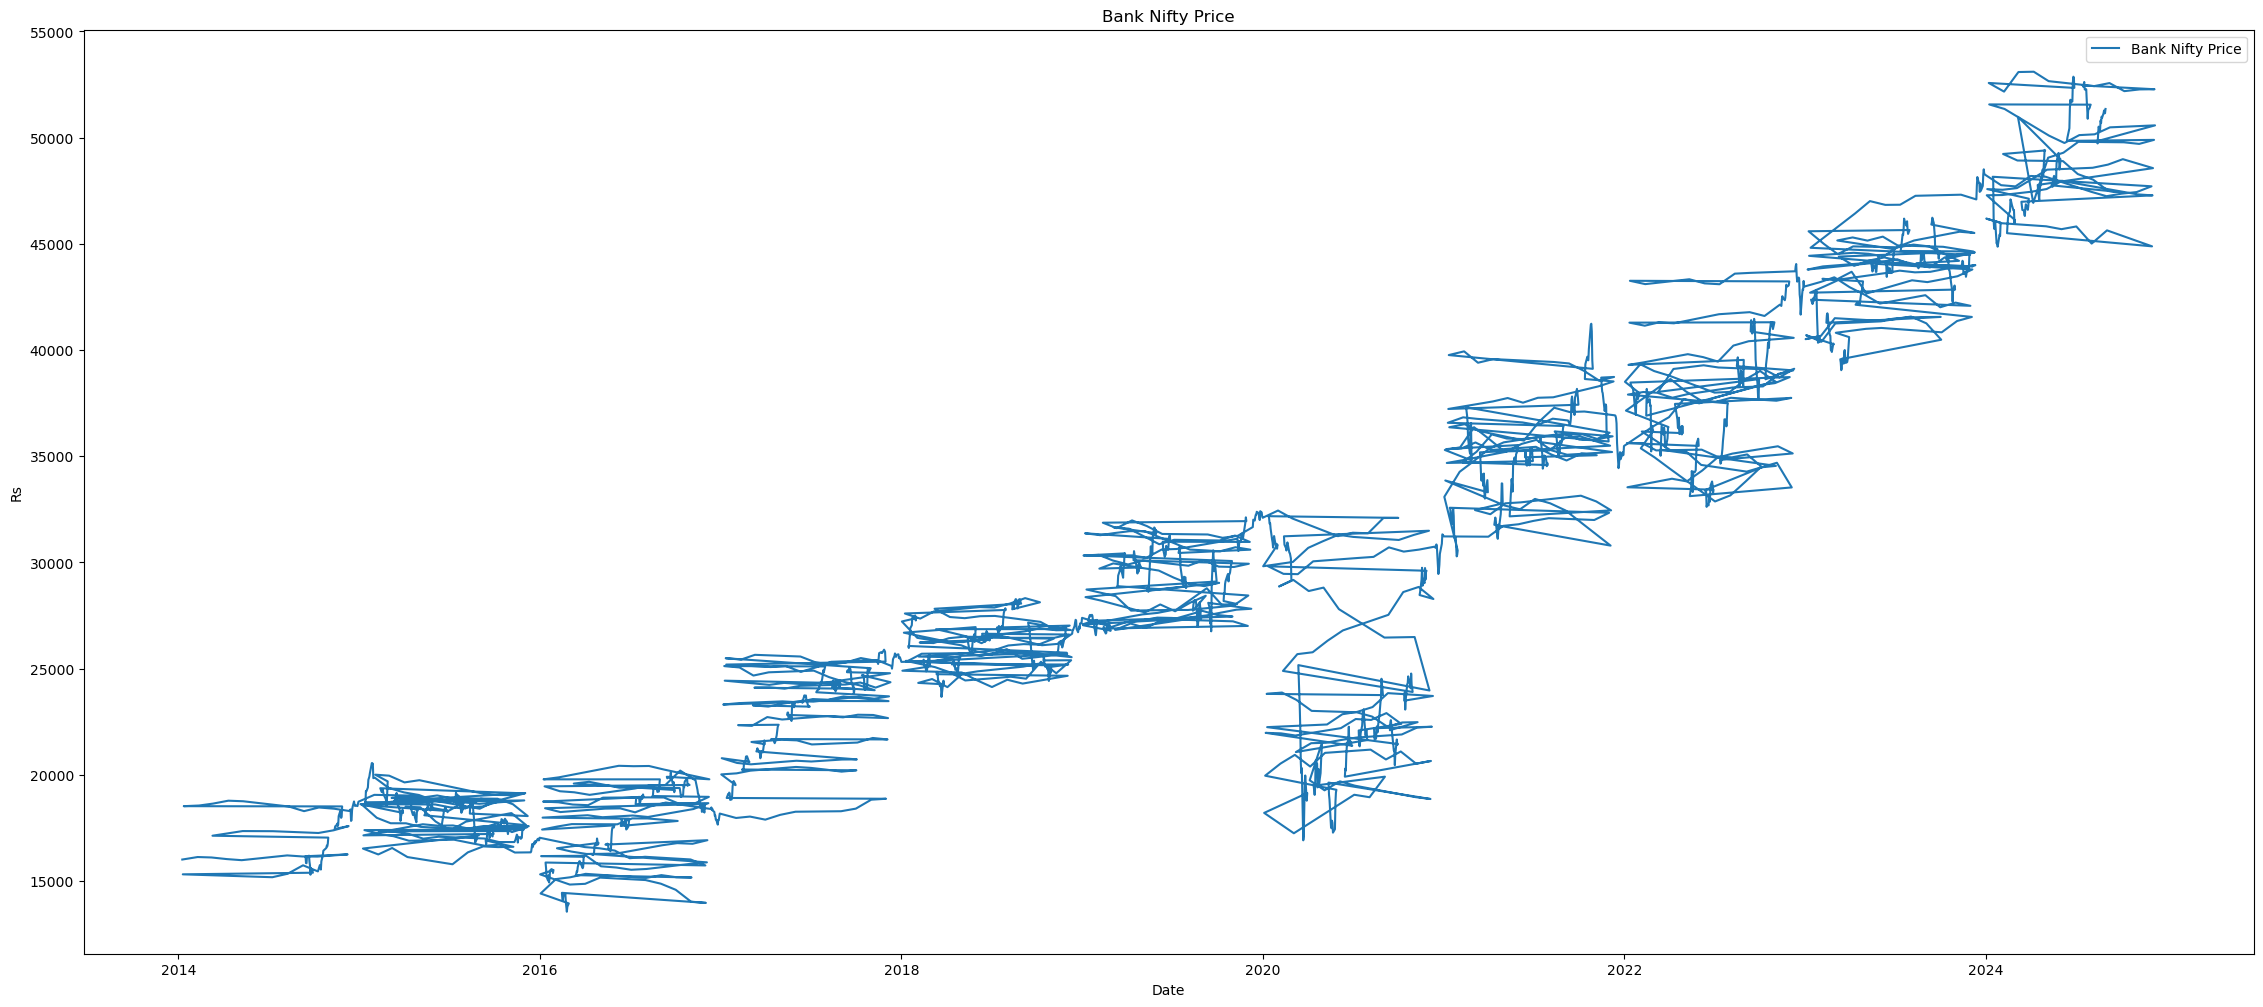

In [5]:
plt.figure(figsize=(28, 12))#, dpi=100)
plt.plot(data.index, data['Price'], label='Bank Nifty Price')
plt.xlabel('Date')
plt.ylabel('Rs')
plt.title('Bank Nifty Price')
plt.legend()
plt.show()

In [6]:
def get_technical_indicators(dataset):
    # Create 7 and 21 days Moving Average
    dataset['ma7'] = dataset['Price'].rolling(window=7).mean()
    dataset['ma21'] = dataset['Price'].rolling(window=21).mean()
    
    # Create MACD
    dataset['26ema'] = dataset['Price'].ewm(span=26).mean()
    dataset['12ema'] = dataset['Price'].ewm(span=12).mean()
    dataset['MACD'] = dataset['12ema']-dataset['26ema']

    # Create Bollinger Bands
    dataset['20sd'] = dataset['Price'].rolling(window = 21).std()
    dataset['upper_band'] = dataset['ma21'] + (dataset['20sd']*2)
    dataset['lower_band'] = dataset['ma21'] - (dataset['20sd']*2)
    
    # Create Exponential moving average
    dataset['ema'] = dataset['Price'].ewm(com=0.5).mean()
    
    # Create Momentum
    dataset['momentum'] = dataset['Price']-1
    dataset['log_momentum'] = np.log(dataset['momentum'])
    return dataset

In [7]:
df = get_technical_indicators(data)

In [8]:
df = df.dropna()
df.head()

,Price,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,log_momentum
Date,,,,,,,,,,,,
2024-01-08,51564.00,50502.107143,50667.590476,50593.900135,50606.064503,12.164368,568.697260,51804.984996,49530.195957,51345.318388,51563.00,10.850560
2024-07-31,51553.40,50654.807143,50677.228571,50680.994353,50755.598299,74.603945,582.408390,51842.045351,49512.411792,51484.039463,51552.40,10.850354
2024-07-30,51499.30,50846.607143,50693.730952,50754.052507,50872.521411,118.468904,601.163561,51896.058075,49491.403829,51494.213154,51498.30,10.849304
2024-07-29,51406.25,51030.500000,50706.226190,50811.408422,50956.151056,144.742634,613.585774,51933.397738,49479.054643,51435.571051,51405.25,10.847496
2024-07-26,51295.95,51251.592857,50707.045238,50853.437370,51009.243012,155.805643,614.399162,51935.843562,49478.246914,51342.490350,51294.95,10.845348


In [9]:
def plot_technical_indicators(dataset, last_days):
    plt.figure(figsize=(16, 10), dpi=100)
    shape_0 = dataset.shape[0]
    xmacd_ = shape_0-last_days
    
    dataset = dataset.iloc[-last_days:, :]
    x_ = range(3, dataset.shape[0])
    x_ =list(dataset.index)

    plt.figure(figsize=(30,20))
    # Plot first subplot
    plt.subplot(2, 1, 1)
    plt.plot(dataset['ma7'],label='MA 7', color='g',linestyle='--')
    plt.plot(dataset['Price'],label='Closing Price', color='b')
    plt.plot(dataset['ma21'],label='MA 21', color='r',linestyle='--')
    plt.plot(dataset['upper_band'],label='Upper Band', color='c')
    plt.plot(dataset['lower_band'],label='Lower Band', color='c')
    plt.fill_between(x_, dataset['lower_band'], dataset['upper_band'], alpha=0.35)
    plt.title('Technical indicators for Goldman Sachs - last {} days.'.format(last_days))
    plt.ylabel('USD')
    plt.legend()

    # Plot second subplot

    plt.subplot(2, 1, 2)
    plt.title('MACD')
    plt.plot(dataset['MACD'],label='MACD', linestyle='-.')
#     plt.hlines(15, xmacd_, shape_0, colors='g', linestyles='--')
#     plt.hlines(-15, xmacd_, shape_0, colors='g', linestyles='--')
    plt.plot(dataset['log_momentum'],label='Momentum', color='b',linestyle='-')

    plt.legend()
    plt.show()

<Figure size 1600x1000 with 0 Axes>

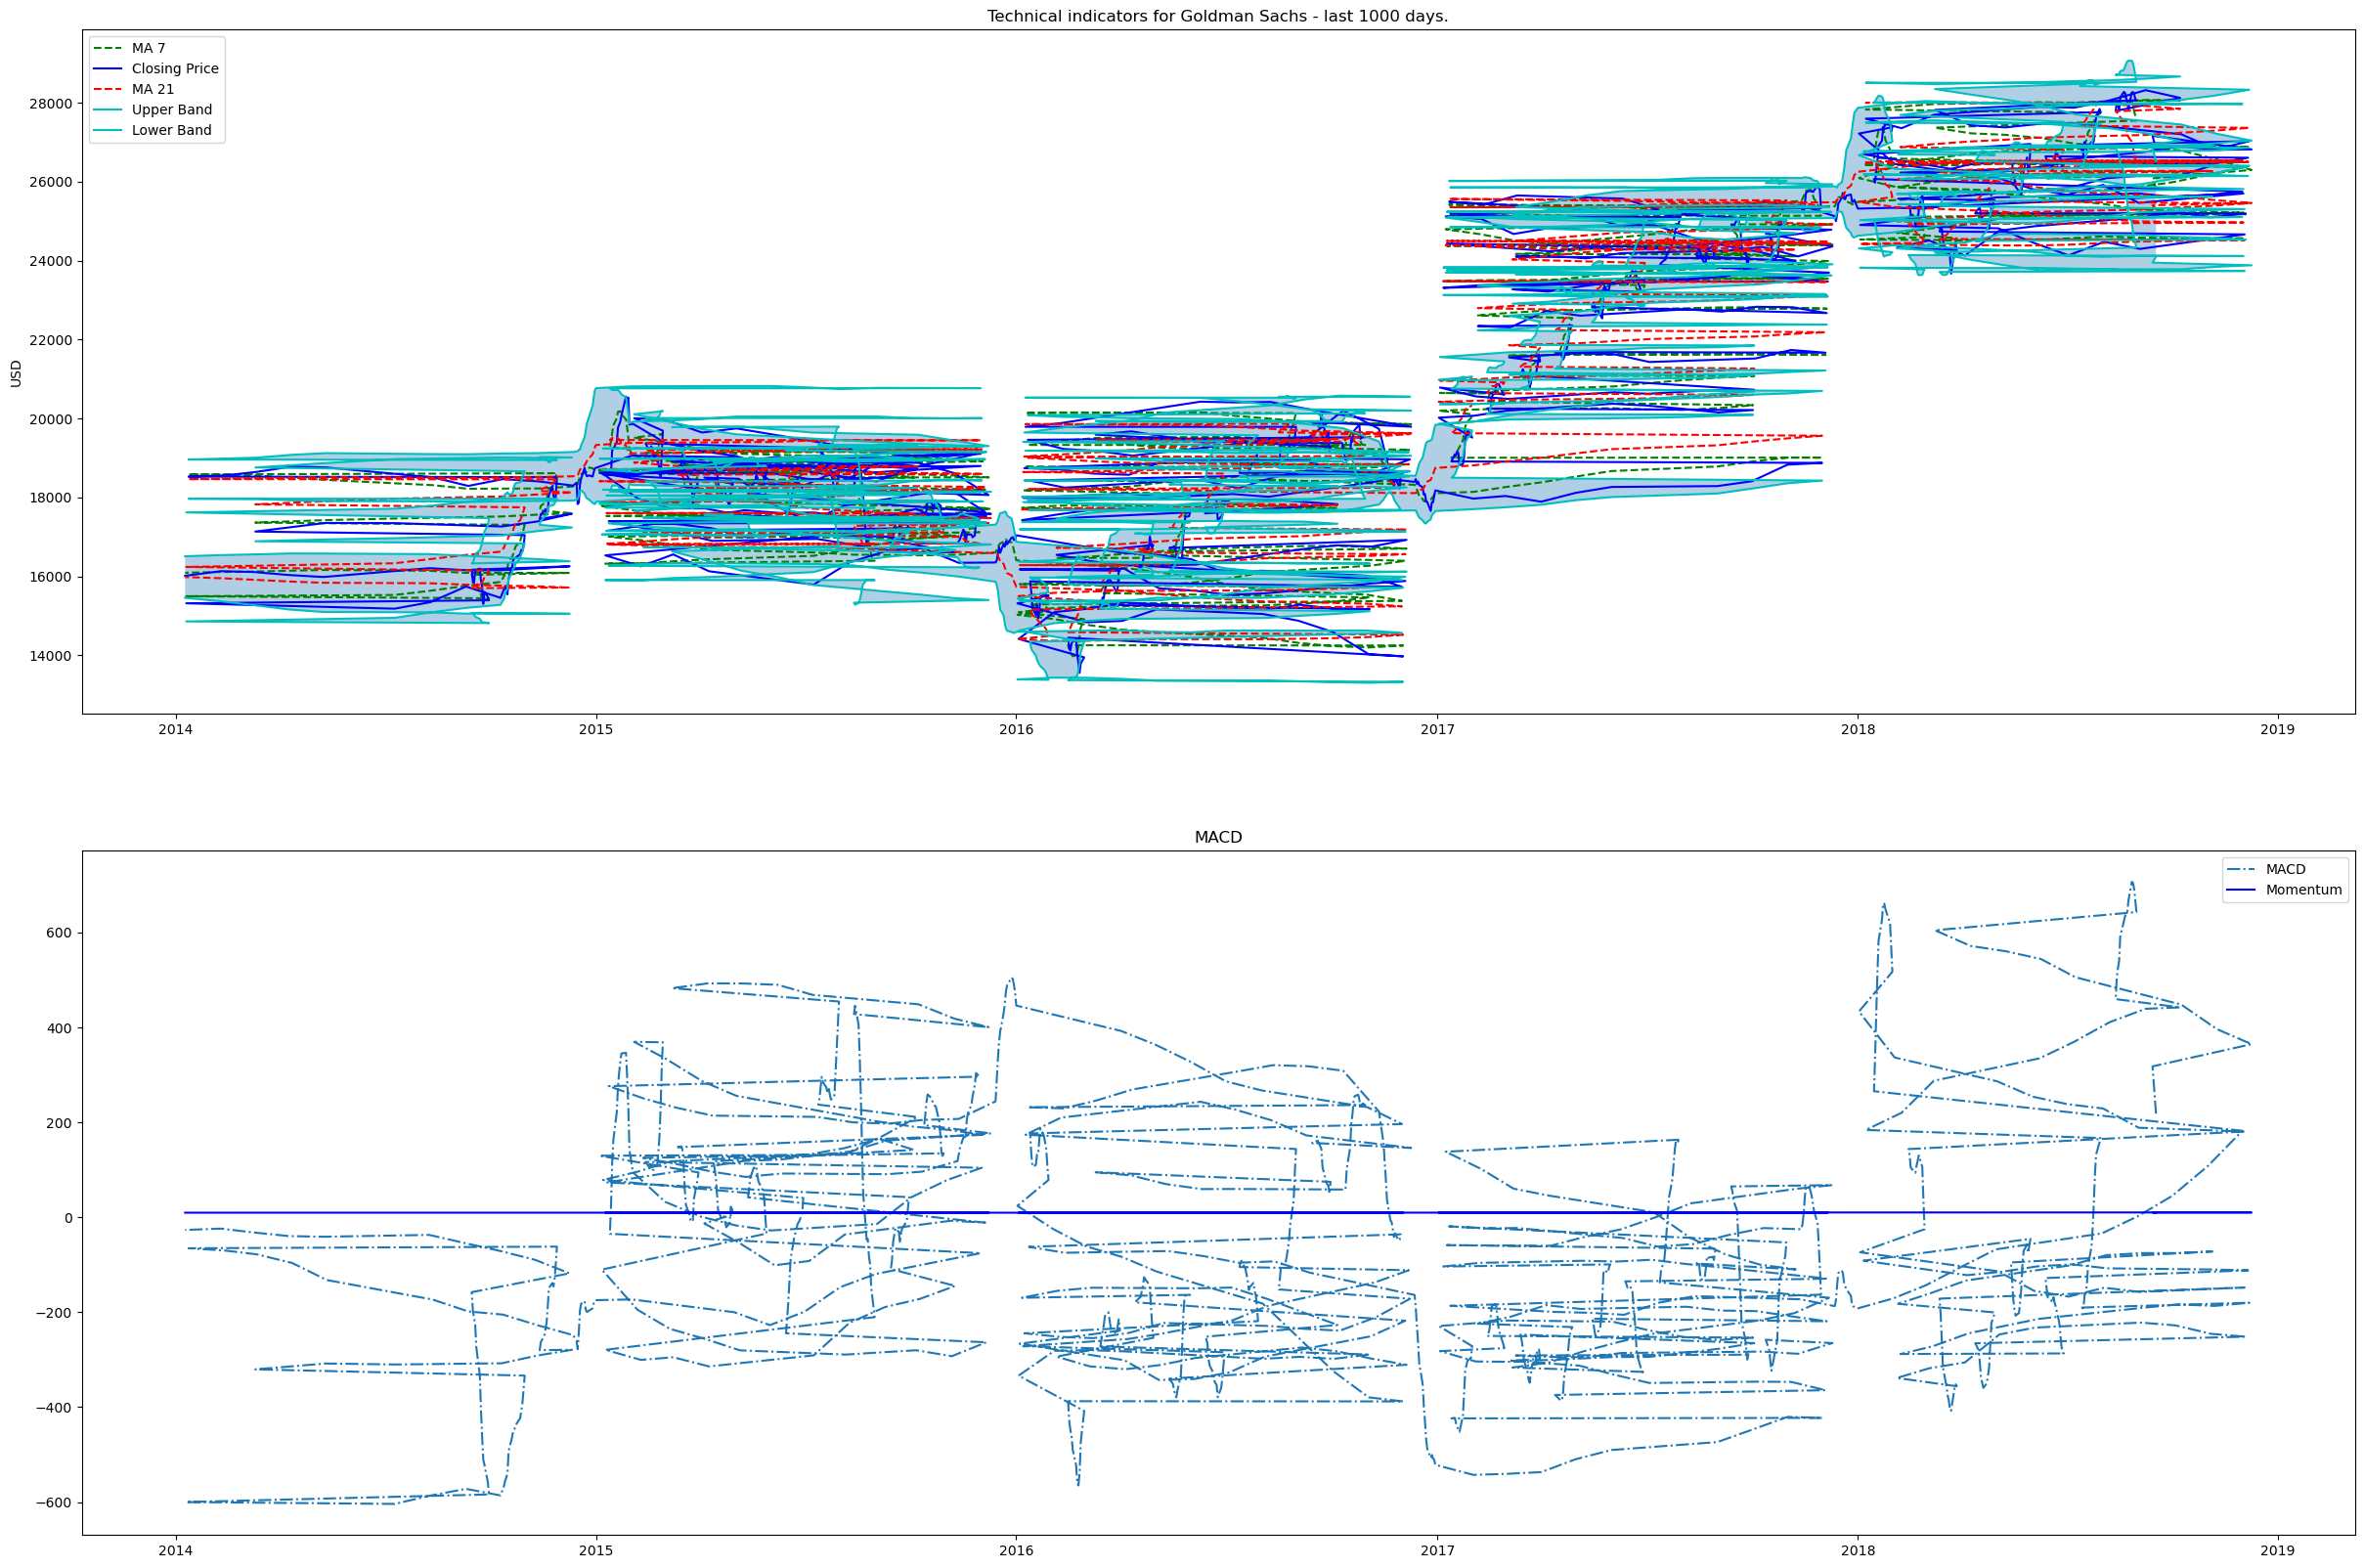

In [10]:
plot_technical_indicators(df, 1000)

Text(0.5, 1.0, 'Params')

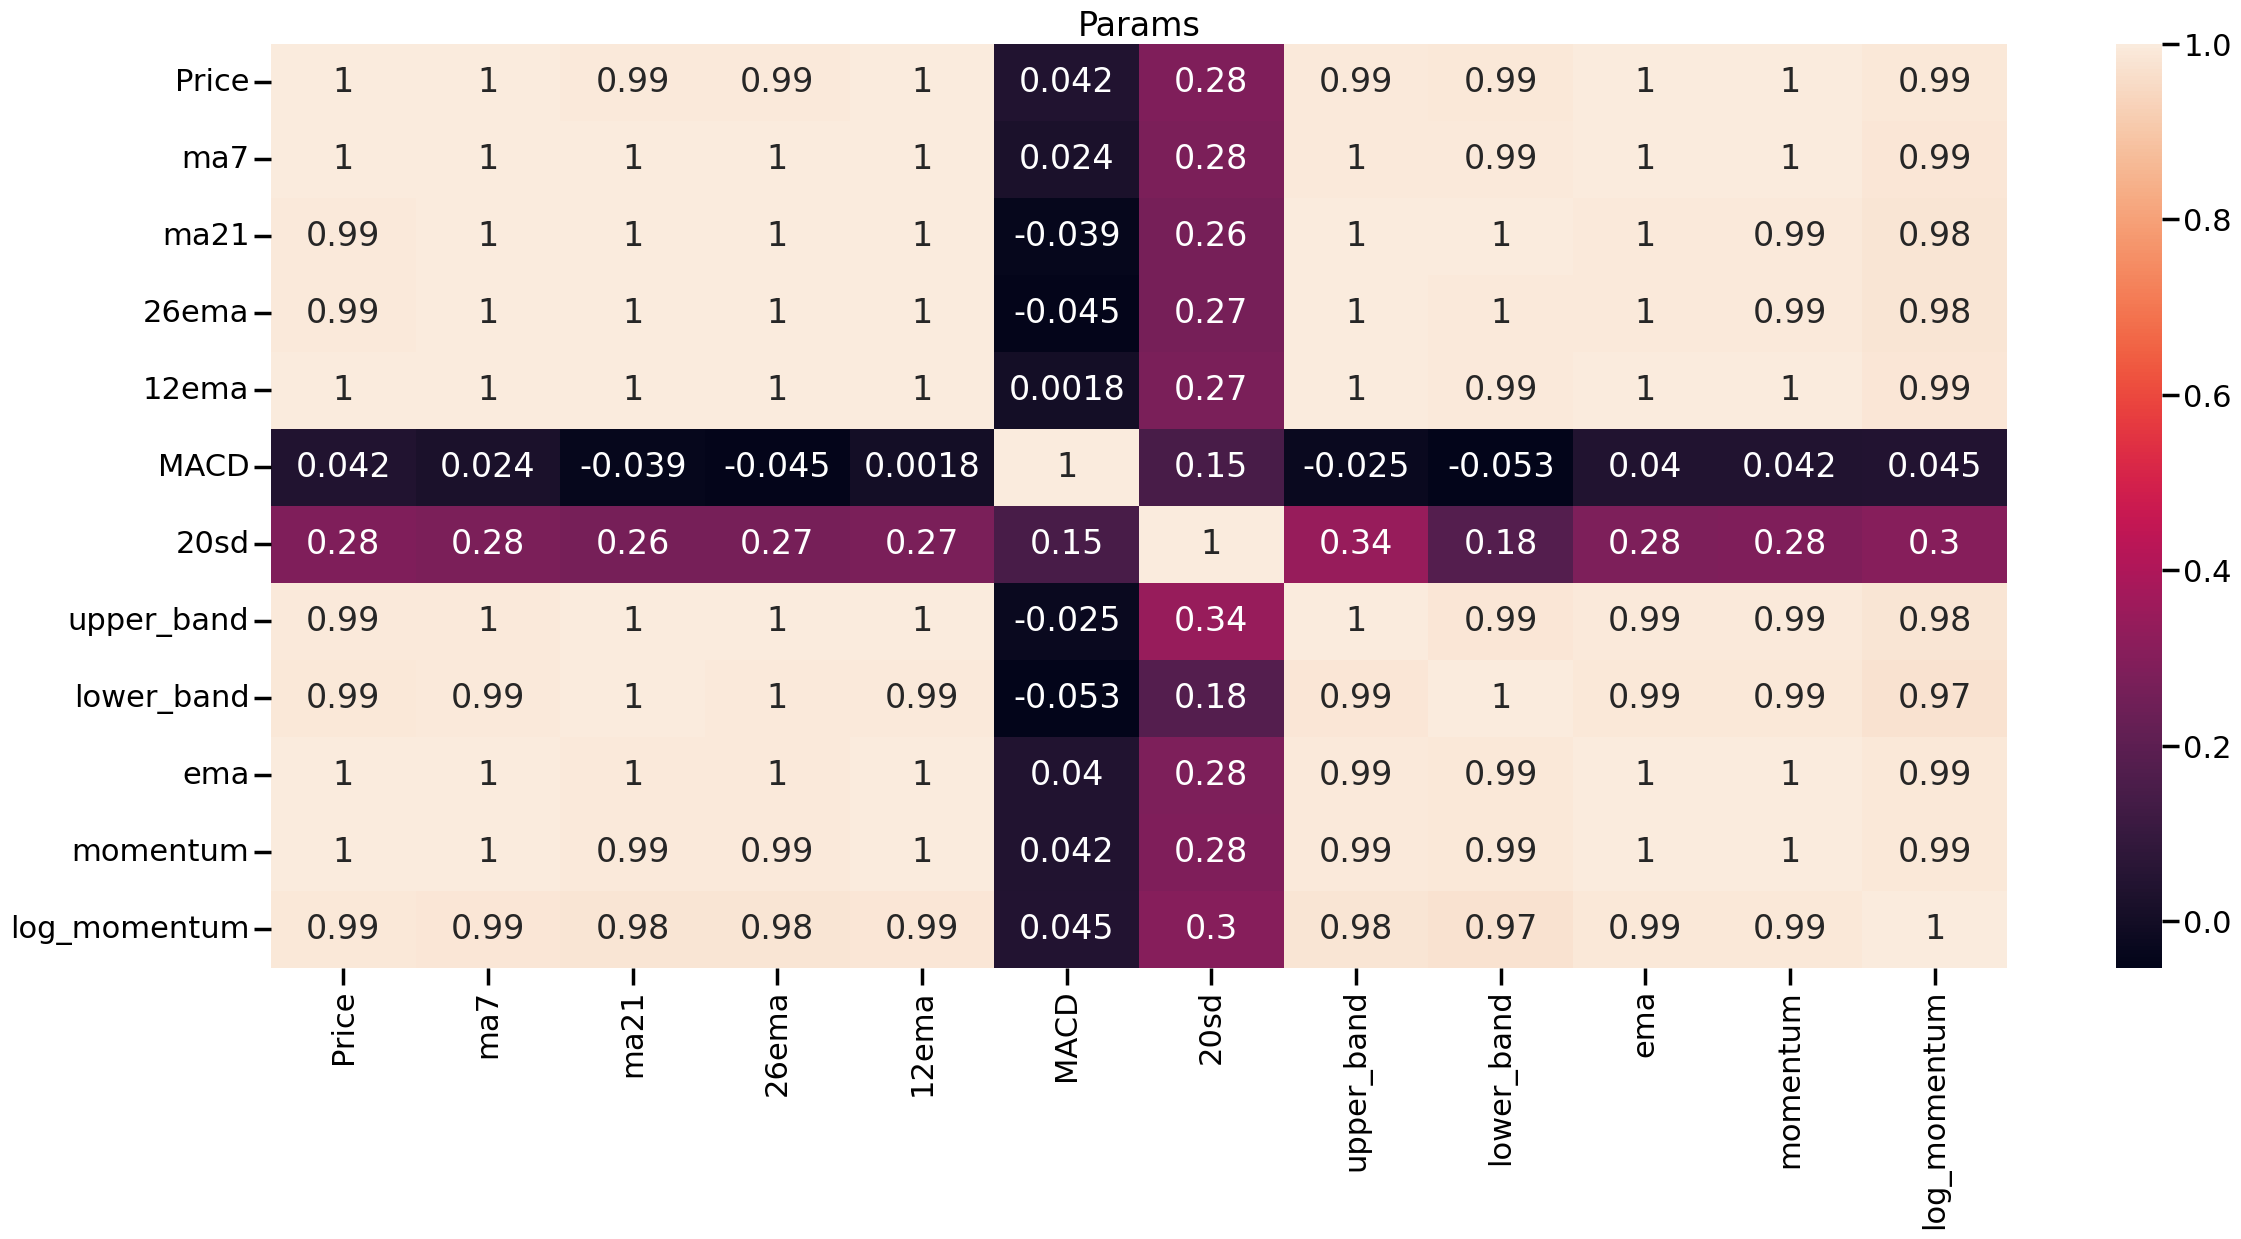

In [11]:
plt.figure(figsize = (28,12))
sns.set_context('poster',font_scale=1)
sns.heatmap(df.corr(), annot = True).set_title('Params')


In [12]:
print('Total dataset has {} samples, and {} features.'.format(df.shape[0], \
                                                              df.shape[1]))

Total dataset has 2454 samples, and 12 features.


In [13]:
df.columns

Index(['Price', 'ma7', 'ma21', '26ema', '12ema', 'MACD', '20sd', 'upper_band',
       'lower_band', 'ema', 'momentum', 'log_momentum'],
      dtype='object')

In [14]:
df

,Price,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,log_momentum
Date,,,,,,,,,,,,
2024-01-08,51564.00,50502.107143,50667.590476,50593.900135,50606.064503,12.164368,568.697260,51804.984996,49530.195957,51345.318388,51563.00,10.850560
2024-07-31,51553.40,50654.807143,50677.228571,50680.994353,50755.598299,74.603945,582.408390,51842.045351,49512.411792,51484.039463,51552.40,10.850354
2024-07-30,51499.30,50846.607143,50693.730952,50754.052507,50872.521411,118.468904,601.163561,51896.058075,49491.403829,51494.213154,51498.30,10.849304
2024-07-29,51406.25,51030.500000,50706.226190,50811.408422,50956.151056,144.742634,613.585774,51933.397738,49479.054643,51435.571051,51405.25,10.847496
2024-07-26,51295.95,51251.592857,50707.045238,50853.437370,51009.243012,155.805643,614.399162,51935.843562,49478.246914,51342.490350,51294.95,10.845348
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-05-09,15982.50,16160.507143,15836.452381,16094.318151,16053.310015,-41.008136,370.007282,16576.466945,15096.437817,16052.098898,15981.50,9.679187
2014-04-09,16033.55,16141.364286,15869.288095,16089.816806,16050.270012,-39.546794,354.387079,16578.062253,15160.513937,16039.732966,16032.55,9.682376
2014-03-09,16110.00,16120.771429,15913.561905,16091.311858,16059.459241,-31.852616,320.453521,16554.468947,15272.654862,16086.577655,16109.00,9.687133


In [15]:
data_training = df[df.index < '2024-01-31'].copy()
data_training

,Price,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,log_momentum
Date,,,,,,,,,,,,
2024-01-08,51564.00,50502.107143,50667.590476,50593.900135,50606.064503,12.164368,568.697260,51804.984996,49530.195957,51345.318388,51563.00,10.850560
2024-01-07,52574.75,52655.821429,52168.311905,52077.936035,52451.972396,374.036361,593.517202,53355.346308,50981.277501,52535.684772,52573.75,10.869972
2024-01-04,47578.25,48087.721429,48233.288095,48231.962971,48018.088228,-213.874743,670.067840,49573.423775,46893.152416,47598.152681,47577.25,10.770110
2024-01-03,47286.90,47535.792857,47088.238095,47417.846256,47327.243323,-90.602933,478.750178,48045.738452,46130.737739,47316.116917,47285.90,10.763967
2024-01-02,46188.65,45734.428571,46127.011905,46269.763165,45930.849618,-338.913547,607.892504,47342.796913,44911.226897,46093.826587,46187.65,10.740468
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-05-09,15982.50,16160.507143,15836.452381,16094.318151,16053.310015,-41.008136,370.007282,16576.466945,15096.437817,16052.098898,15981.50,9.679187
2014-04-09,16033.55,16141.364286,15869.288095,16089.816806,16050.270012,-39.546794,354.387079,16578.062253,15160.513937,16039.732966,16032.55,9.682376
2014-03-09,16110.00,16120.771429,15913.561905,16091.311858,16059.459241,-31.852616,320.453521,16554.468947,15272.654862,16086.577655,16109.00,9.687133


In [16]:
data_testing = df[df.index >= '2024-01-31'].copy()
data_testing

,Price,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,log_momentum
Date,,,,,,,,,,,,
2024-07-31,51553.40,50654.807143,50677.228571,50680.994353,50755.598299,74.603945,582.408390,51842.045351,49512.411792,51484.039463,51552.40,10.850354
2024-07-30,51499.30,50846.607143,50693.730952,50754.052507,50872.521411,118.468904,601.163561,51896.058075,49491.403829,51494.213154,51498.30,10.849304
2024-07-29,51406.25,51030.500000,50706.226190,50811.408422,50956.151056,144.742634,613.585774,51933.397738,49479.054643,51435.571051,51405.25,10.847496
2024-07-26,51295.95,51251.592857,50707.045238,50853.437370,51009.243012,155.805643,614.399162,51935.843562,49478.246914,51342.490350,51294.95,10.845348
2024-07-25,50888.75,51365.400000,50694.695238,50856.462064,50990.461614,133.999550,607.659895,51910.015028,49479.375449,51039.996783,50887.75,10.837378
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,47450.25,47640.757143,46308.052381,46601.848273,46967.353656,365.505383,1044.578931,48397.210243,44218.894519,47401.209016,47449.25,10.767416
2024-05-01,48159.00,47645.600000,46425.585714,46717.193289,47150.683863,433.490573,1108.553419,48642.692553,44208.478876,47906.403005,48158.00,10.782243
2024-04-01,48195.85,47650.964286,46538.457143,46826.723806,47311.478653,484.754847,1163.702438,48865.862020,44211.052266,48099.367668,48194.85,10.783007


In [17]:
scalar = MinMaxScaler()

data_training_scaled = scalar.fit_transform(data_training)
print(data_training_scaled.shape)
data_training_scaled

(2325, 12)


array([[0.97409599, 0.94432089, 0.96029956, ..., 0.96936626, 0.97409599,
        0.98567848],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.87194716, 0.88190274, 0.89590194, ..., 0.87293402, 0.87194716,
        0.92632722],
       ...,
       [0.0654629 , 0.05547396, 0.04090814, ..., 0.06199262, 0.0654629 ,
        0.12736766],
       [0.06598956, 0.05520213, 0.041934  , ..., 0.06274703, 0.06598956,
        0.12830819],
       [0.0629718 , 0.05468896, 0.04271572, ..., 0.06097832, 0.0629718 ,
        0.1229027 ]])

In [18]:
X_train = []
y_train = []

In [19]:
for i in range(60, data_training.shape[0]):
    X_train.append(data_training_scaled[i-60: i])
    y_train.append(data_training_scaled[i, 0])

In [20]:
X_train, y_train = np.array(X_train), np.array(y_train)
X_train.shape, y_train.shape

((2265, 60, 12), (2265,))

In [21]:
regressor = Sequential()

regressor.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (X_train.shape[1], 12)))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
regressor.add(Dropout(0.4))

regressor.add(LSTM(units = 120, activation = 'relu'))
regressor.add(Dropout(0.5))

regressor.add(Dense(units = 1))

In [22]:
regressor.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 50)            12600     
                                                                 
 dropout (Dropout)           (None, 60, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 60, 60)            26640     
                                                                 
 dropout_1 (Dropout)         (None, 60, 60)            0         
                                                                 
 lstm_2 (LSTM)               (None, 60, 80)            45120     
                                                                 
 dropout_2 (Dropout)         (None, 60, 80)            0         
                                                                 
 lstm_3 (LSTM)               (None, 120)               9

In [23]:
# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [24]:
regressor.fit(X_train, y_train, epochs=500, batch_size = 64)

Epoch 1/500
36/36 [==============================] - 7s 109ms/step - loss: 0.0215
Epoch 2/500
36/36 [==============================] - 4s 107ms/step - loss: 0.0075
Epoch 3/500
36/36 [==============================] - 4s 111ms/step - loss: 0.0064
Epoch 4/500
36/36 [==============================] - 4s 108ms/step - loss: 0.0055
Epoch 5/500
36/36 [==============================] - 4s 112ms/step - loss: 0.0056
Epoch 6/500
36/36 [==============================] - 4s 114ms/step - loss: 0.0049
Epoch 7/500
36/36 [==============================] - 4s 113ms/step - loss: 0.0049
Epoch 8/500
36/36 [==============================] - 4s 112ms/step - loss: 0.0041
Epoch 9/500
36/36 [==============================] - 4s 112ms/step - loss: 0.0041
Epoch 10/500
36/36 [==============================] - 4s 112ms/step - loss: 0.0042
Epoch 11/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0041
Epoch 12/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0038
Epoch 13/500


36/36 [==============================] - 4s 123ms/step - loss: 0.0016
Epoch 100/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0016
Epoch 101/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0015
Epoch 102/500
36/36 [==============================] - 4s 120ms/step - loss: 0.0015
Epoch 103/500
36/36 [==============================] - 4s 120ms/step - loss: 0.0015
Epoch 104/500
36/36 [==============================] - 4s 118ms/step - loss: 0.0015
Epoch 105/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0016
Epoch 106/500
36/36 [==============================] - 4s 123ms/step - loss: 0.0016
Epoch 107/500
36/36 [==============================] - 5s 125ms/step - loss: 0.0015
Epoch 108/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0015
Epoch 109/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0015
Epoch 110/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0014
Epoch 

36/36 [==============================] - 4s 118ms/step - loss: 0.0014
Epoch 197/500
36/36 [==============================] - 4s 120ms/step - loss: 0.0013
Epoch 198/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0014
Epoch 199/500
36/36 [==============================] - 4s 120ms/step - loss: 0.0014
Epoch 200/500
36/36 [==============================] - 4s 120ms/step - loss: 0.0014
Epoch 201/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0013
Epoch 202/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0014
Epoch 203/500
36/36 [==============================] - 4s 120ms/step - loss: 0.0013
Epoch 204/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0014
Epoch 205/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0014
Epoch 206/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0016
Epoch 207/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0013
Epoch 

36/36 [==============================] - 4s 121ms/step - loss: 0.0014
Epoch 294/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0013
Epoch 295/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0014
Epoch 296/500
36/36 [==============================] - 4s 119ms/step - loss: 0.0015
Epoch 297/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0013
Epoch 298/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0013
Epoch 299/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0014
Epoch 300/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0013
Epoch 301/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0013
Epoch 302/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0013
Epoch 303/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0014
Epoch 304/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0014
Epoch 

36/36 [==============================] - 4s 123ms/step - loss: 0.0013
Epoch 391/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0012
Epoch 392/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0014
Epoch 393/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0012
Epoch 394/500
36/36 [==============================] - 4s 123ms/step - loss: 0.0012
Epoch 395/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0012
Epoch 396/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0013
Epoch 397/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0012
Epoch 398/500
36/36 [==============================] - 4s 123ms/step - loss: 0.0012
Epoch 399/500
36/36 [==============================] - 4s 123ms/step - loss: 0.0012
Epoch 400/500
36/36 [==============================] - 4s 123ms/step - loss: 0.0013
Epoch 401/500
36/36 [==============================] - 4s 121ms/step - loss: 0.0013
Epoch 

36/36 [==============================] - 4s 124ms/step - loss: 0.0012
Epoch 488/500
36/36 [==============================] - 4s 125ms/step - loss: 0.0012
Epoch 489/500
36/36 [==============================] - 5s 125ms/step - loss: 0.0013
Epoch 490/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0012
Epoch 491/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0012
Epoch 492/500
36/36 [==============================] - 4s 124ms/step - loss: 0.0013
Epoch 493/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0012
Epoch 494/500
36/36 [==============================] - 4s 123ms/step - loss: 0.0013
Epoch 495/500
36/36 [==============================] - 4s 125ms/step - loss: 0.0013
Epoch 496/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0012
Epoch 497/500
36/36 [==============================] - 4s 120ms/step - loss: 0.0013
Epoch 498/500
36/36 [==============================] - 4s 122ms/step - loss: 0.0012
Epoch 

In [35]:
regressor.evaluate(X_test,y_test)

5/5 [==============================] - 0s 18ms/step - loss: 1127778688.0000


1127778688.0

In [25]:
past_60 = data_training.tail(60)

dt = past_60.append(data_testing, ignore_index = True)
dt

C:\Users\RISHI\AppData\Local\Temp\ipykernel_13020\175218773.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dt = past_60.append(data_testing, ignore_index = True)


,Price,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,log_momentum
0,18555.85,18572.135714,18473.350000,18601.795404,18531.893086,-69.902319,255.150965,18983.651930,17963.048070,18596.346537,18554.85,9.828486
1,18525.30,18581.042857,18463.285714,18596.129078,18530.878765,-65.250313,248.322887,18959.931489,17966.639940,18548.982179,18524.30,9.826839
2,18513.15,18612.828571,18456.885714,18589.982480,18528.151263,-61.831217,245.046739,18946.979192,17966.792236,18525.094060,18512.15,9.826183
3,18022.50,18543.178571,18432.797619,18547.946741,18450.358761,-97.587980,261.950084,18956.697787,17908.897452,18190.031353,18021.50,9.799321
4,17975.95,18431.635714,18405.119048,18505.576612,18377.372797,-128.203814,278.343542,18961.806133,17848.431963,18047.310451,17974.95,9.796734
...,...,...,...,...,...,...,...,...,...,...,...,...
184,47450.25,47640.757143,46308.052381,46601.848273,46967.353656,365.505383,1044.578931,48397.210243,44218.894519,47401.209016,47449.25,10.767416
185,48159.00,47645.600000,46425.585714,46717.193289,47150.683863,433.490573,1108.553419,48642.692553,44208.478876,47906.403005,48158.00,10.782243
186,48195.85,47650.964286,46538.457143,46826.723806,47311.478653,484.754847,1163.702438,48865.862020,44211.052266,48099.367668,48194.85,10.783007
187,47704.95,47650.271429,46621.028571,46891.777813,47372.012707,480.234893,1182.783363,48986.595298,44255.461845,47836.422556,47703.95,10.772769


In [26]:
inputs = scalar.fit_transform(dt)
print(inputs.shape)
inputs

(189, 12)


array([[0.08901089, 0.08568062, 0.07545827, ..., 0.08804453, 0.08901089,
        0.16034664],
       [0.08820532, 0.0859192 , 0.07518442, ..., 0.08679035, 0.08820532,
        0.1590308 ],
       [0.08788494, 0.08677055, 0.07501027, ..., 0.08615781, 0.08788494,
        0.15850688],
       ...,
       [0.87058535, 0.86453619, 0.83912837, ..., 0.86926841, 0.87058535,
        0.9225619 ],
       [0.85764085, 0.86451764, 0.8413752 , ..., 0.86230577, 0.85764085,
        0.91438656],
       [0.85913597, 0.86575469, 0.8434134 , ..., 0.86098581, 0.85913597,
        0.91533512]])

In [27]:
X_test = []
y_test = []

for i in range(60, inputs.shape[0]):
    X_test.append(inputs[i-60:i])
    y_test.append(inputs[i, 0])
    
X_test, y_test = np.array(X_test), np.array(y_test)
X_test.shape, y_test.shape

((129, 60, 12), (129,))

In [28]:
y_pred = regressor.predict(X_test)

5/5 [==============================] - 0s 18ms/step


In [29]:
y_pred

array([[0.1367799 ],
       [0.2194409 ],
       [0.2252338 ],
       [0.22812238],
       [0.25506186],
       [0.27809623],
       [0.35312715],
       [0.45468122],
       [0.54177576],
       [0.6037128 ],
       [0.65627   ],
       [0.6835301 ],
       [0.70616496],
       [0.72022   ],
       [0.7305296 ],
       [0.7372541 ],
       [0.7487347 ],
       [0.75611264],
       [0.76310694],
       [0.7733084 ],
       [0.7800971 ],
       [0.77877927],
       [0.77951944],
       [0.7867303 ],
       [0.7921727 ],
       [0.79323864],
       [0.7872585 ],
       [0.7794514 ],
       [0.778709  ],
       [0.7741345 ],
       [0.75749516],
       [0.7356722 ],
       [0.71726793],
       [0.7069581 ],
       [0.6977257 ],
       [0.69314104],
       [0.6945448 ],
       [0.69040585],
       [0.6842695 ],
       [0.6652851 ],
       [0.702755  ],
       [0.71222794],
       [0.7066788 ],
       [0.6923522 ],
       [0.70076704],
       [0.7214804 ],
       [0.72708666],
       [0.724

In [30]:
scale = 1/scalar.scale_[0]

In [31]:
y_pred = y_pred*scale
y_test = y_test*scale

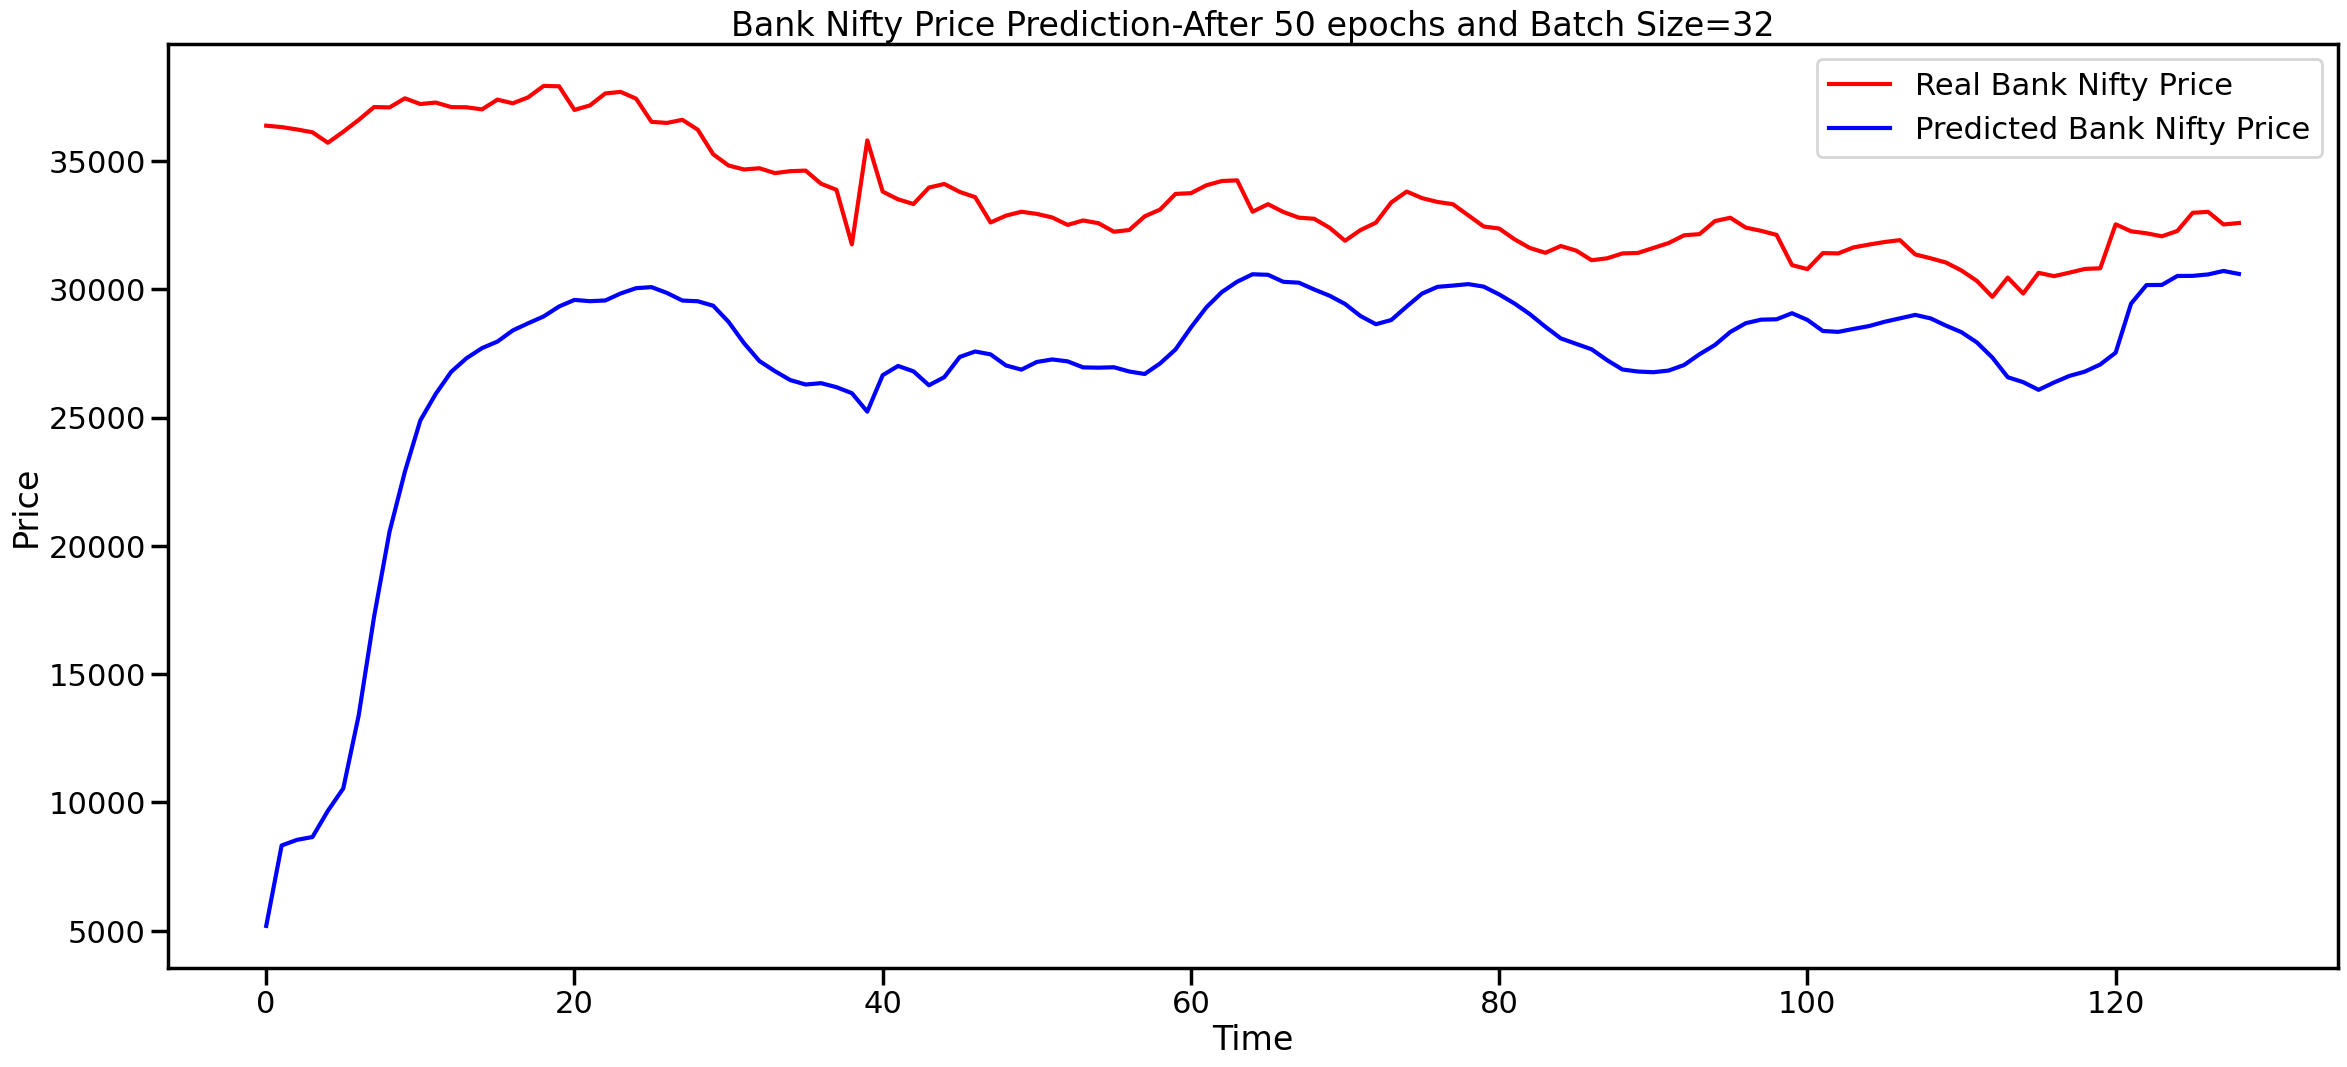

In [34]:
# Visualising the results
plt.figure(figsize=(28,12))
plt.plot(y_test, color = 'red', label = 'Real Bank Nifty Price')
plt.plot(y_pred, color = 'blue', label = 'Predicted Bank Nifty Price')
plt.title('Bank Nifty Price Prediction-After 50 epochs and Batch Size=32')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()